### 2 序列模型
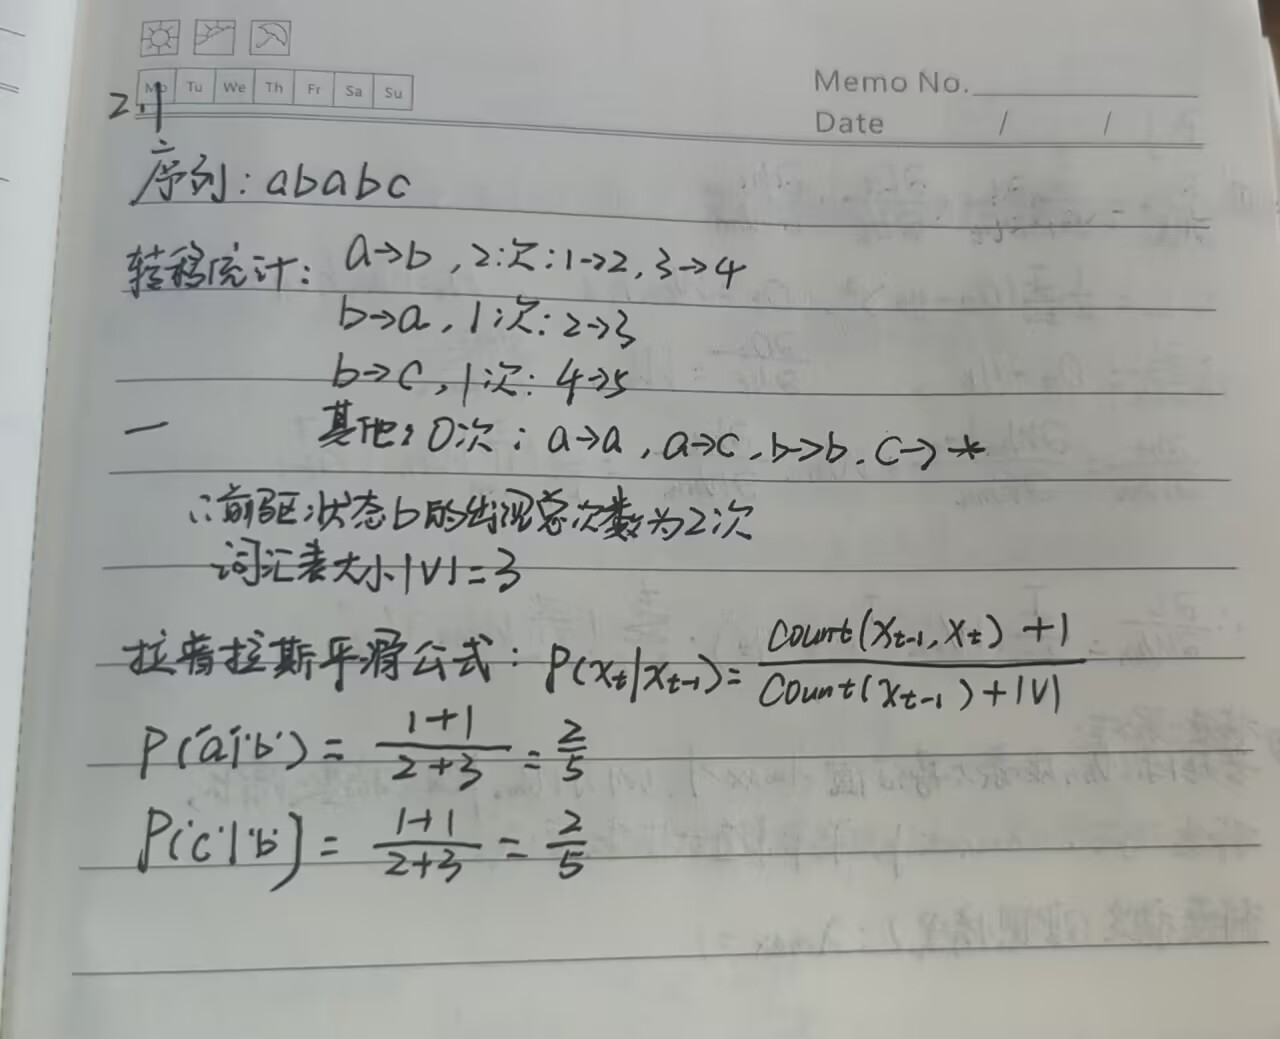

In [ ]:
import re
from collections import Counter

def preprocess_text(text,n):
    """
    参数:
        text: 原始字符串
        n: 滑动窗口长度
    返回:
        vocab: 字典 {词: ID}，按频率降序排列
        features: 列表，每个元素为长度为 n 的词列表
        labels: 列表，每个元素为窗口之后的下一个词（若不存在则为None）
    """
    # 1. 转小写，去除非字母和空格的字符
    clean=re.sub(r'[^a-zA-Z\s]','',text).lower()
    # 2. 按空格分词（多个空格会分出空串，这里用 split() 自动过滤空串）
    words=clean.split()
    
    # 3. 构建词汇表（按频率降序，ID从0开始）
    freq=Counter(words)
    vocab={word: idx for idx,(word,_) in enumerate(freq.most_common())}
    
    # 4. 滑动窗口生成特征和标签
    features=[]
    labels=[]
    for i in range(len(words)-n):
        features.append(words[i:i+n])
        labels.append(words[i+n])          # 窗口后的下一个词
    # 如果窗口超出末尾，则忽略（题目要求“若无后续词则忽略”）
    # 但若 len(words)-n < 0，则无特征，返回空列表
    
    return vocab,features,labels

# 测试
if __name__ == "__main__":
    text="The time machine"
    vocab,features,labels=preprocess_text(text,2)
    print("词汇表:",vocab)
    print("特征:",features)
    print("标签:",labels)

词汇表: {'the': 0, 'time': 1, 'machine': 2}
特征: [['the', 'time']]
标签: ['machine']


### 3 循环神经网络
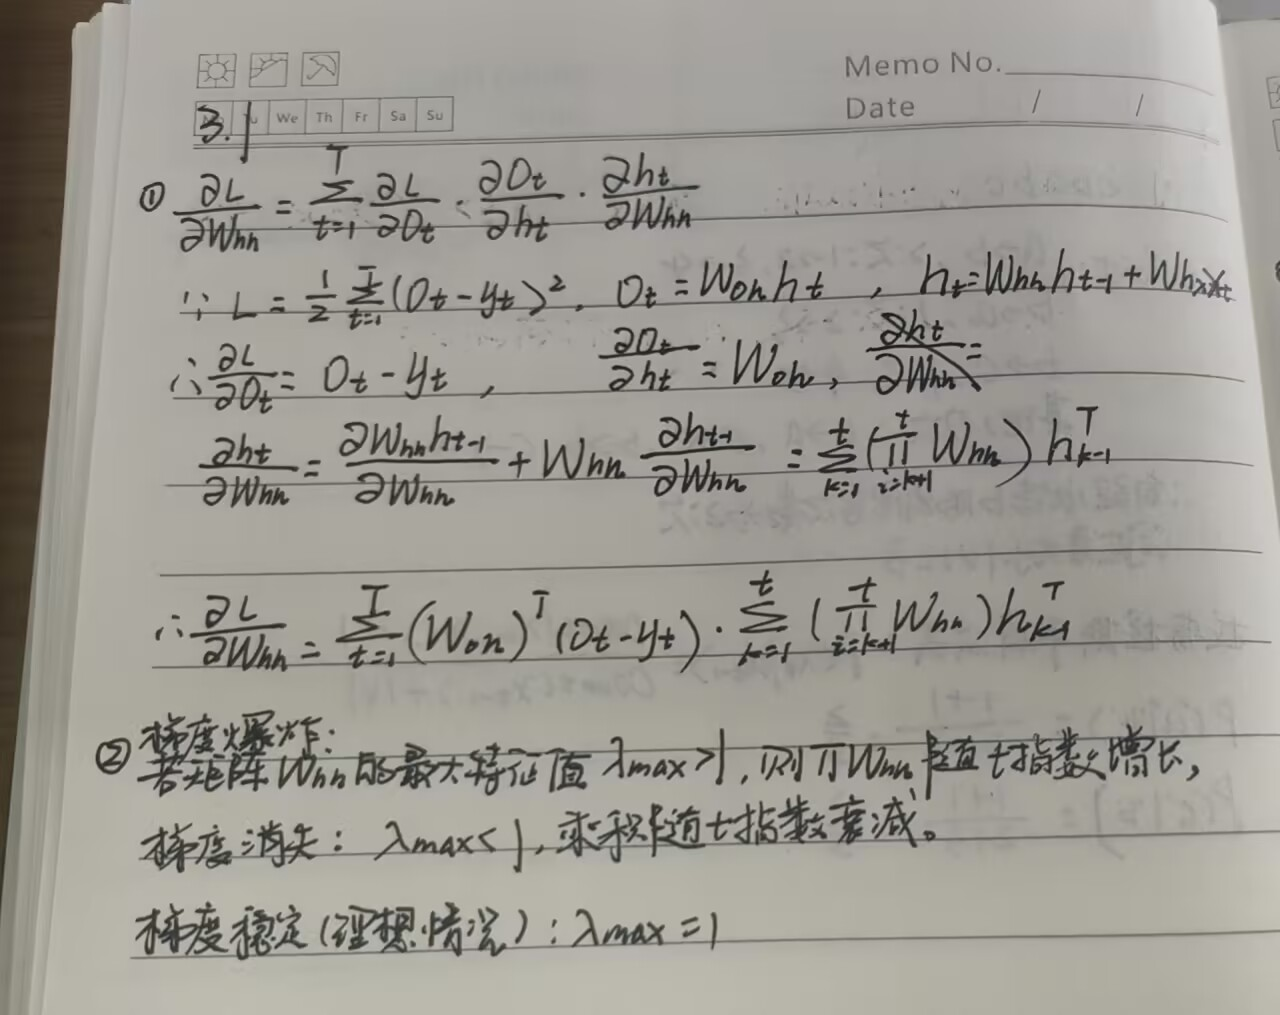

In [ ]:
import numpy as np

def rnn_cell_forward(x_t,h_prev,W_hx,W_hh,b_h):
    """
    单步前向传播，激活函数 tanh
    输入:
        x_t: (input_size,batch_size)  注意形状为 (特征,批量)
        h_prev: (hidden_size,batch_size)
        W_hx: (hidden_size,input_size)
        W_hh: (hidden_size,hidden_size)
        b_h: (hidden_size,1)
    返回:
        h_t: (hidden_size, batch_size)
    """
    h_t=np.tanh(np.dot(W_hx,x_t)+np.dot(W_hh,h_prev)+b_h)
    return h_t

def rnn_cell_backward(dh_next,x_t,h_prev,h_t,W_hx,W_hh):
    """
    单步反向传播
    输入:
        dh_next: 损失对 h_t 的梯度，形状 (hidden_size,batch_size)
        x_t,h_prev,h_t: 同前向
        W_hx,W_hh: 权重
    返回:
        dx_t,dh_prev: 对输入和前一隐藏状态的梯度
        dW_hx,dW_hh,db_h: 对参数的梯度
    """
    # tanh 导数: 1 - tanh^2
    dtanh=dh_next * (1 - h_t ** 2)          # (hidden_size, batch_size)
    
    # 对权重的梯度（注意矩阵乘法的转置）
    dW_hx=np.dot(dtanh,x_t.T)              # (hidden_size, input_size)
    dW_hh=np.dot(dtanh,h_prev.T)           # (hidden_size, hidden_size)
    db_h=np.sum(dtanh,axis=1,keepdims=True)  # (hidden_size, 1)
    
    # 对输入的梯度
    dx_t=np.dot(W_hx.T,dtanh)              # (input_size, batch_size)
    dh_prev=np.dot(W_hh.T,dtanh)           # (hidden_size, batch_size)
    
    return dx_t,dh_prev,dW_hx,dW_hh,db_h

# 测试代码（可放在另一个单元格）
if __name__ == "__main__":
    batch,in_dim,hid_dim=3,4,5
    x_t=np.random.randn(in_dim,batch)
    h_prev=np.random.randn(hid_dim,batch)
    W_hx=np.random.randn(hid_dim,in_dim)
    W_hh=np.random.randn(hid_dim,hid_dim)
    b_h=np.random.randn(hid_dim,1)
    
    h_t=rnn_cell_forward(x_t,h_prev,W_hx,W_hh,b_h)
    dh_next=np.random.randn(hid_dim,batch)
    dx,dh_prev_g,dWx,dWh,db=rnn_cell_backward(dh_next,x_t,h_prev,h_t,W_hx,W_hh)
    print("前向输出 h_t 形状:",h_t.shape)
    print("dW_hx 形状:",dWx.shape)
    print("dW_hh 形状:",dWh.shape)

前向输出 h_t 形状: (5, 3)
dW_hx 形状: (5, 4)
dW_hh 形状: (5, 5)


### 4 高级循环神经网络
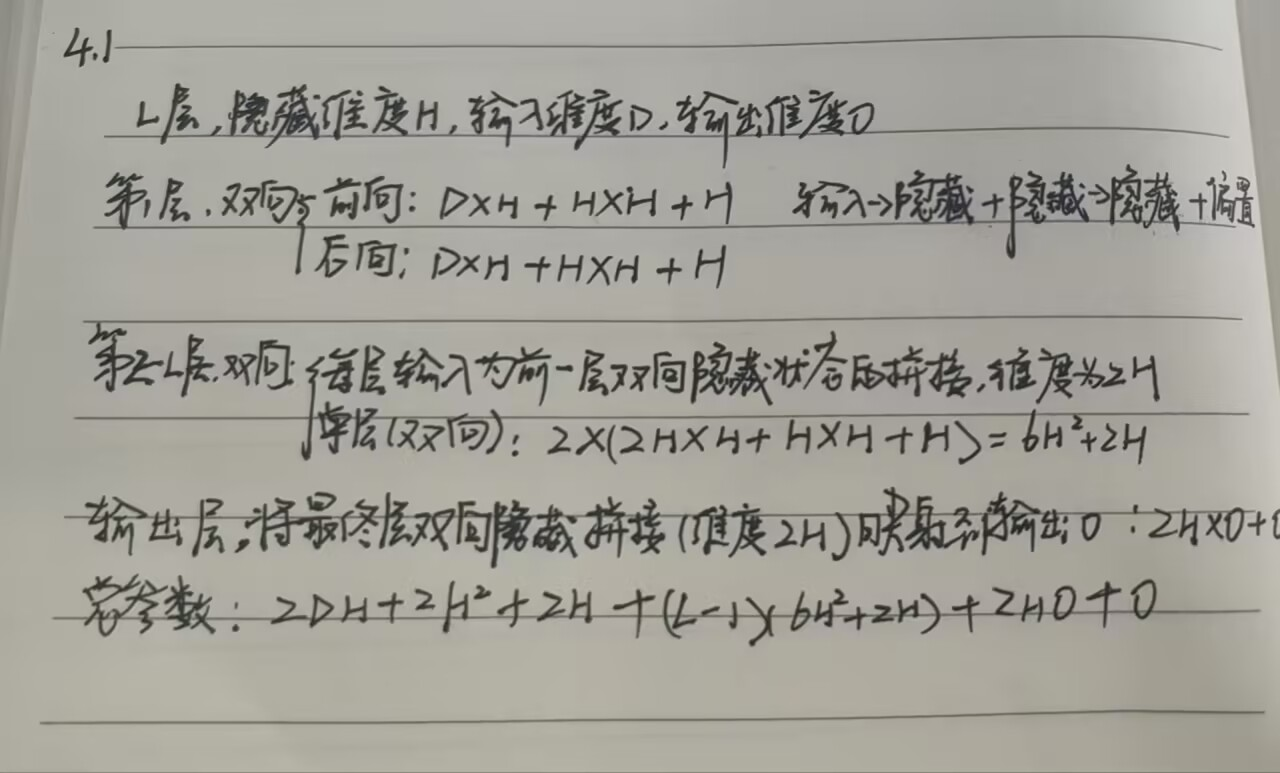

In [ ]:
import torch
import torch.nn as nn

def bidirectional_rnn_encoder(X,input_dim,hidden_dim,num_layers):
    """
    使用 PyTorch 的 RNN 实现双向编码器
    参数:
        X: (seq_len, batch, input_dim)
        input_dim: 输入维度
        hidden_dim: 每层隐藏单元数
        num_layers: 层数
    返回:
        outputs: (seq_len, batch, 2*hidden_dim)  每个时间步的双向拼接
        final_state: (batch, 2*hidden_dim)       最终时间步的拼接隐藏状态（作为序列表示）
    """
    rnn=nn.RNN(
        input_size=input_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        batch_first=False,          # 保持 (seq, batch, feature)
        bidirectional=True
    )
    outputs,h_n=rnn(X)   # outputs: (seq, batch, 2*H)
                            # h_n: (num_layers*2, batch, H)
    
    # 取最后一层的前向和后向的最终状态
    # 前向：最后一层（索引 -2）的最后时间步（即 outputs 最后时刻）
    # 后向：最后一层（索引 -1）的最后时间步（即 outputs 第一时刻）
    forward_last=h_n[-2,:,:]   # (batch, H)
    backward_last=h_n[-1,:,:]  # (batch, H)
    final_state=torch.cat([forward_last, backward_last], dim=1)  # (batch, 2H)
    
    return outputs,final_state

# 测试
if __name__ == "__main__":
    seq_len,batch,in_dim,hid_dim,layers=5, 2, 3, 4, 2
    X=torch.randn(seq_len,batch,in_dim)
    outputs,final=bidirectional_rnn_encoder(X, in_dim, hid_dim, layers)
    print("outputs 形状:",outputs.shape)   # (5, 2, 8)
    print("final_state 形状:",final.shape) # (2, 8)

outputs 形状: torch.Size([5, 2, 8])
final_state 形状: torch.Size([2, 8])


### 5 嵌入向量
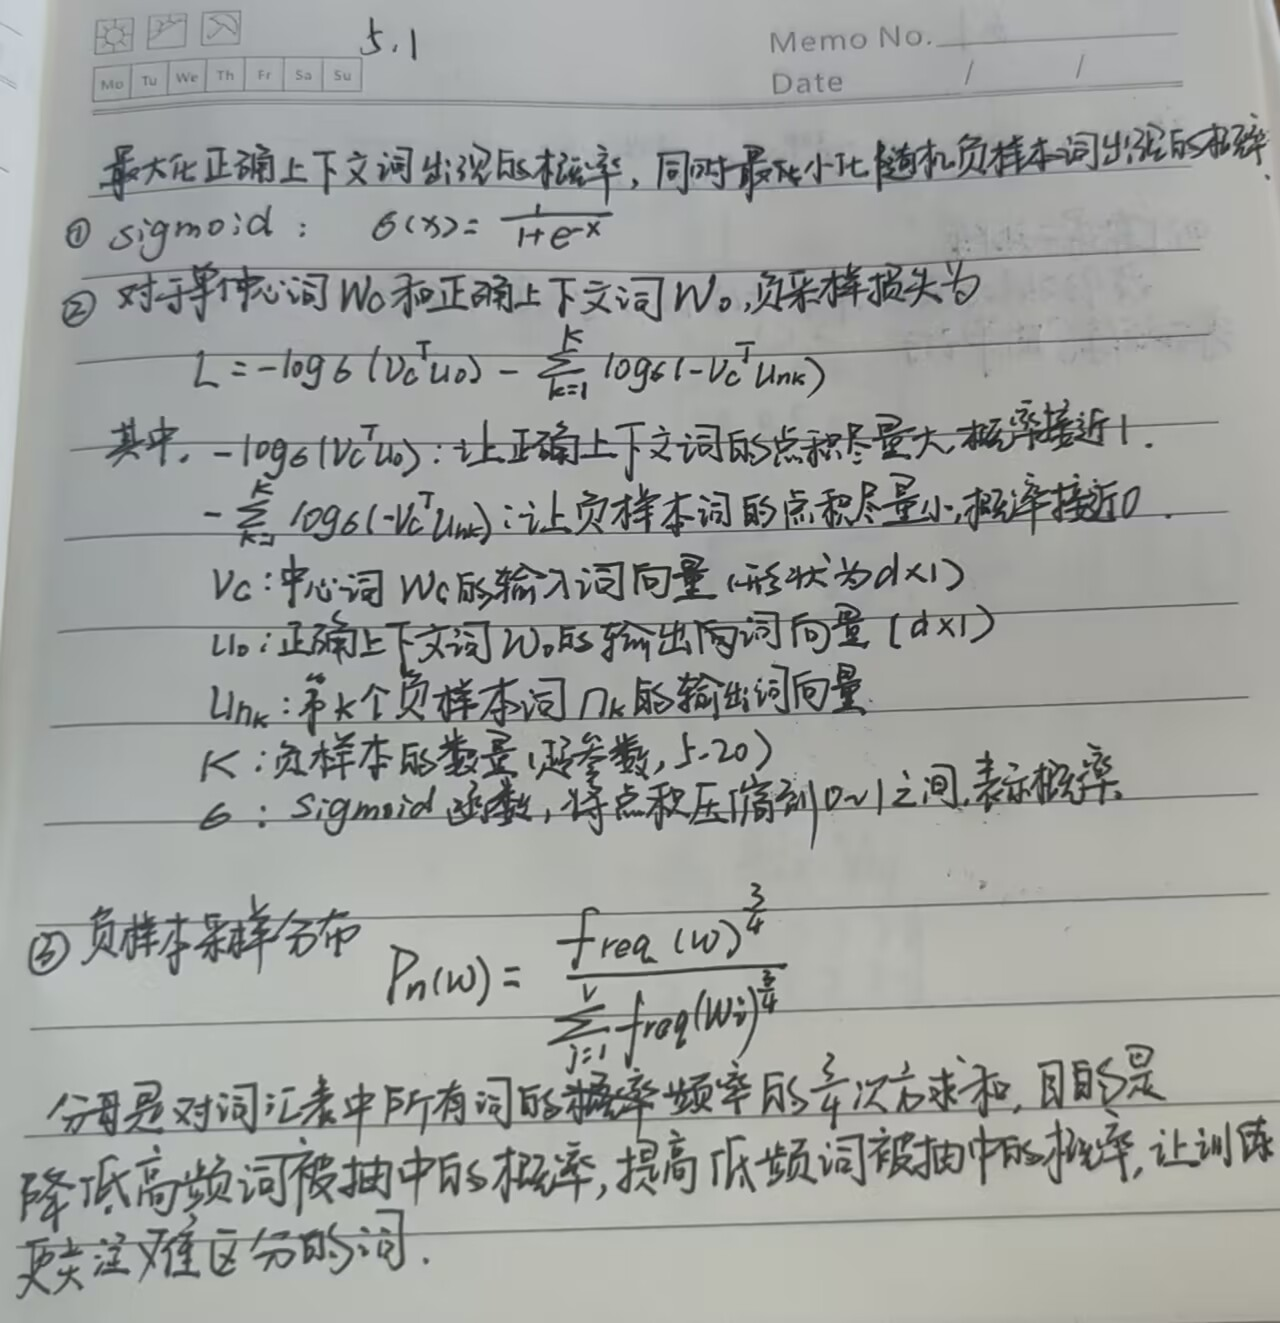

In [ ]:
import torch
import torch.nn.functional as F

def cbow_forward(context_indices,target_indices,W,W_out):
    """
    参数:
        context_indices: (batch_size, context_size) 上下文词ID
        target_indices:  (batch_size,) 中心词ID
        W: (V, d) 输入嵌入矩阵
        W_out: (d, V) 输出权重矩阵
    返回:
        交叉熵损失 (标量)
    """
    # 1. 获取上下文词向量并求平均（隐藏层）
    # W[context_indices] 形状: (batch,context_size, d)
    h=W[context_indices].mean(dim=1)          # (batch, d)
    
    # 2. 计算输出 logits（形状 batch x V）
    logits=torch.matmul(h,W_out)             # (batch, V)
    
    # 3. 计算交叉熵损失（target为类别索引）
    loss=F.cross_entropy(logits,target_indices)
    return loss

# 测试代码
if __name__ == "__main__":
    V,d,batch, ctx_size=10,4,2,3
    W=torch.randn(V,d,requires_grad=True)
    W_out=torch.randn(d,V,requires_grad=True)
    context=torch.randint(0,V,(batch,ctx_size))
    target=torch.randint(0,V,(batch,))
    loss=cbow_forward(context,target,W,W_out)
    print("CBOW 损失:",loss.item())

CBOW 损失: 5.449368476867676


### 6 注意力机制
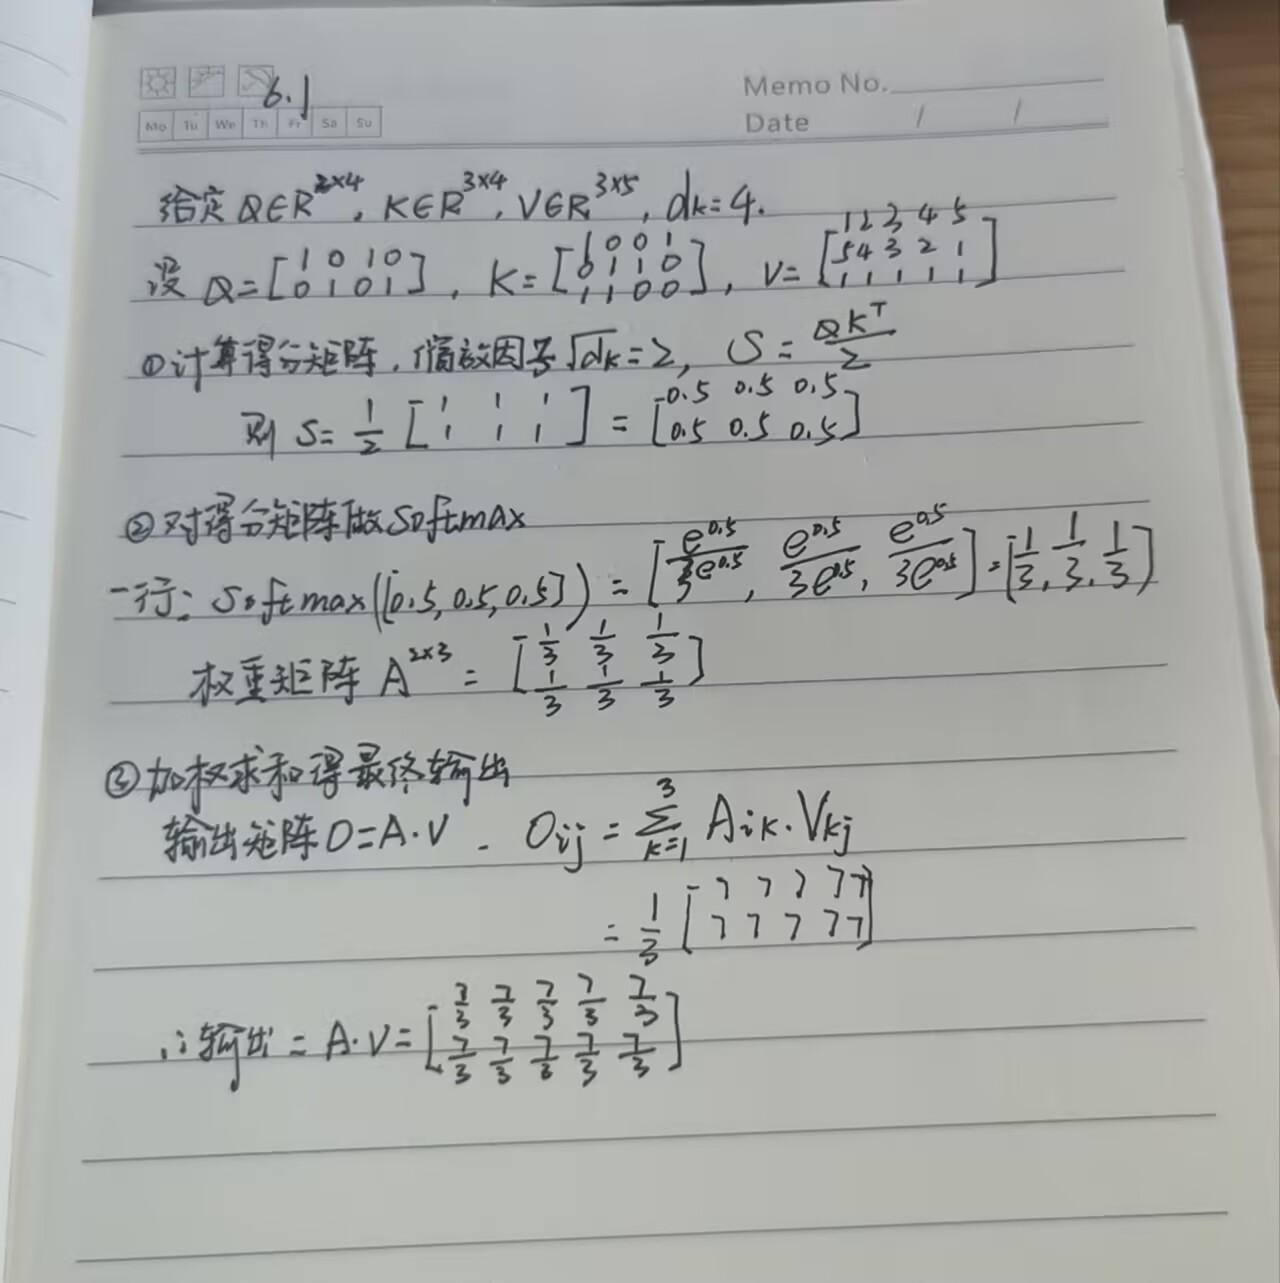

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self,d_model,num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model=d_model
        self.num_heads=num_heads
        self.d_k=d_model // num_heads
        
        # 线性投影层（无偏置）
        self.W_q=nn.Linear(d_model,d_model,bias=False)
        self.W_k=nn.Linear(d_model,d_model,bias=False)
        self.W_v=nn.Linear(d_model,d_model,bias=False)
        self.W_o=nn.Linear(d_model,d_model,bias=False)
        
    def forward(self, X):
        """
        X: (seq_len, batch, d_model)
        返回: (seq_len, batch, d_model)
        """
        seq_len, batch, _=X.shape
        
        # 1. 线性投影并拆分为多头 (seq, batch, num_heads, d_k)
        Q=self.W_q(X).view(seq_len,batch,self.num_heads,self.d_k)
        K=self.W_k(X).view(seq_len,batch,self.num_heads,self.d_k)
        V=self.W_v(X).view(seq_len,batch,self.num_heads,self.d_k)
        
        # 2. 转置为 (batch, num_heads, seq_len, d_k) 便于批量矩阵乘法
        Q=Q.permute(1,2,0,3)
        K=K.permute(1,2,0,3)
        V=V.permute(1,2,0,3)
        
        # 3. 缩放点积注意力
        scores=torch.matmul(Q,K.transpose(-2, -1)) / (self.d_k ** 0.5)  # (batch, heads, seq, seq)
        attn_weights=F.softmax(scores,dim=-1)
        attn_output=torch.matmul(attn_weights,V)  # (batch, heads, seq, d_k)
        
        # 4. 合并多头 -> (seq, batch, d_model)
        attn_output=attn_output.permute(2,0,1,3).contiguous()  # (seq, batch, heads, d_k)
        attn_output=attn_output.view(seq_len,batch,self.d_model)
        
        # 5. 最终线性层
        output=self.W_o(attn_output)
        return output

# 测试
if __name__ == "__main__":
    d_model,num_heads=4,2
    seq_len,batch=3,2
    X=torch.randn(seq_len,batch,d_model)
    model=MultiHeadAttention(d_model,num_heads)
    out=model(X)
    print("多头注意力输出形状:",out.shape)  

多头注意力输出形状: torch.Size([3, 2, 4])
